# 220210_F2_run5 c-GC Connectivity Matrices

This notebook runs `GcStar` with `method="cgc"` on v2a-RSN traces loaded from the `ica-denoising` dataset registry. It saves binary adjacency matrices for later graph-stability analysis and does not compute recovery or stability metrics.

Each dataset pickle is a `dict[int, np.ndarray]` keyed by the configured `N_PAST`, matching the input format used by the v2a-RSN stability analysis notebook. Rerun with another `N_PAST` value to add or replace one conditioning depth.

Trace variants analysed: raw and the `cluster_keep_top_04` cluster-cleaned trace for each BSS method (FastICA, Infomax, SOBI, JADE).


In [1]:
from __future__ import annotations

import json
import sys
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

SEARCH_ROOTS = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next(
    (
        candidate
        for root in SEARCH_ROOTS
        for candidate in (root, root / "ica-denoising")
        if (candidate / "pyproject.toml").exists()
        and (candidate / "src" / "ica_denoising").exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the ica-denoising project root.")

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from ica_denoising.bss_notebook import available_datasets, get_dataset, load_traces

pd.set_option("display.max_colwidth", 120)
print(f"Project root: {PROJECT_ROOT}")


Project root: /Users/sadiq.adedayo/Documents/projects/others/ica-denoising


In [2]:
v2a_datasets = available_datasets(PROJECT_ROOT).query(
    "group == 'v2a-RSNs' and exists"
).reset_index(drop=True)
v2a_datasets[
    ["key", "data_name", "recording_id", "modality", "default_n_components"]
]


,key,data_name,recording_id,modality,default_n_components
0,v2a-RSNs/220119_F2_run11_fluorescence,220119_F2_run11_fluorescence,220119_F2_run11,fluorescence,NaN
1,v2a-RSNs/220119_F2_run11_spike_rate,220119_F2_run11_spike_rate,220119_F2_run11,spike_rate,NaN
2,v2a-RSNs/220127_F4_run2_fluorescence,220127_F4_run2_fluorescence,220127_F4_run2,fluorescence,NaN
3,v2a-RSNs/220127_F4_run2_spike_rate,220127_F4_run2_spike_rate,220127_F4_run2,spike_rate,NaN
4,v2a-RSNs/220210_F1_run6_fluorescence,220210_F1_run6_fluorescence,220210_F1_run6,fluorescence,NaN
5,v2a-RSNs/220210_F1_run6_spike_rate,220210_F1_run6_spike_rate,220210_F1_run6,spike_rate,NaN
6,v2a-RSNs/220210_F2_run5_fluorescence,220210_F2_run5_fluorescence,220210_F2_run5,fluorescence,NaN
7,v2a-RSNs/220210_F2_run5_spike_rate,220210_F2_run5_spike_rate,220210_F2_run5,spike_rate,NaN


In [3]:
METHOD_LABEL = "c-GC"
GCSTAR_METHOD = "cgc"
N_PAST = 2
N_LAGS = 4
N_PERM = 1000
ALPHA = 0.01
BETA = 0.001
TEMPORAL = True
SIMULATION = False
VERBOSE = 0
REPLACE_EXISTING_P = True

DATASET_KEY = "v2a-RSNs/220210_F2_run5_fluorescence"
CLEANED_METHODS = ("fastica", "infomax", "sobi", "jade")
REQUIRE_SAVED_CLEANED = True
CLEANED_VARIANT = "cluster_keep_top_04"  # raw + top-4 cluster-cleaned traces
VARIANTS_TO_RUN = None  # None = all; or a tuple e.g. ("raw",) / ("fastica_cleaned", "infomax_cleaned")
SKIP_EXISTING = True  # skip a variant whose pickle already holds this run's P/tau result
DATASET = get_dataset(DATASET_KEY, PROJECT_ROOT)
OUTPUT_DATA_NAME = DATASET.recording_id or DATASET.data_name
DATASET_OUTPUT_NAME = OUTPUT_DATA_NAME

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "connectivity" / "v2a-RSNs" / DATASET_OUTPUT_NAME / METHOD_LABEL
WEIGHTED_DIR = OUTPUT_DIR / "weighted"
METADATA_DIR = OUTPUT_DIR / "metadata"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTED_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Method: {METHOD_LABEL} ({GCSTAR_METHOD})")
print(f"Dataset: {DATASET_KEY}")
print(f"Trace variants: raw + {', '.join(CLEANED_METHODS)} ({CLEANED_VARIANT})")
print(f"P value saved by this run: {N_PAST}")
print(f"Connectivity pickles: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}/<variant>.pkl")


Method: c-GC (cgc)
Dataset: v2a-RSNs/220210_F2_run5_fluorescence
Trace variants: raw + fastica, infomax, sobi, jade (cluster_keep_top_04)
P value saved by this run: 2
Connectivity pickles: outputs/connectivity/v2a-RSNs/220210_F2_run5/c-GC/<variant>.pkl


In [4]:
from csl.core import GcStar
from csl.utils import (
    load_bss_trace_variants,
    save_adjacency_dict,
    write_adjacency_dict,
    write_json,
)

TRACE_VARIANTS = load_bss_trace_variants(
    DATASET_KEY,
    PROJECT_ROOT,
    methods=CLEANED_METHODS,
    require_saved_cleaned=REQUIRE_SAVED_CLEANED,
    output_data_name_override=OUTPUT_DATA_NAME,
    cleaned_variant=CLEANED_VARIANT,
)
variant_overview = pd.DataFrame(
    {
        "variant_name": variant["variant_name"],
        "variant_label": variant["variant_label"],
        "source_method": variant["source_method"],
        "source_path": variant["source_path"],
        "trace_shape_neurons_by_frames": [tuple(variant["traces"].shape)],
    }
    for variant in TRACE_VARIANTS
)
variant_overview


,variant_name,variant_label,source_method,source_path,trace_shape_neurons_by_frames
0,raw,220210_F2_run5_fluorescence: raw,NaN,/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/data/v2a-RSNs/220210_F2_run5/220210_F2_F2_run5_cells_fl...,"[(165, 3317)]"
1,fastica_cleaned,220210_F2_run5_fluorescence: fastica (cluster_keep_top_04),fastica,/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/linear/v2a-RSNs/220210_F2_run5/fastica/cleaned_...,"[(165, 3317)]"
2,infomax_cleaned,220210_F2_run5_fluorescence: infomax (cluster_keep_top_04),infomax,/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/linear/v2a-RSNs/220210_F2_run5/infomax/cleaned_...,"[(165, 3317)]"
3,sobi_cleaned,220210_F2_run5_fluorescence: sobi (cluster_keep_top_04),sobi,/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/linear/v2a-RSNs/220210_F2_run5/sobi/cleaned_var...,"[(165, 3317)]"
4,jade_cleaned,220210_F2_run5_fluorescence: jade (cluster_keep_top_04),jade,/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/linear/v2a-RSNs/220210_F2_run5/jade/cleaned_var...,"[(165, 3317)]"


In [5]:
records: list[dict[str, object]] = []

for index, variant in enumerate(TRACE_VARIANTS, start=1):
    spec = variant["dataset"]
    variant_name = str(variant["variant_name"])
    variant_pickle_path = OUTPUT_DIR / f"{variant_name}.pkl"
    if VARIANTS_TO_RUN is not None and variant_name not in VARIANTS_TO_RUN:
        print(f"[{index}/{len(TRACE_VARIANTS)}] Skipping {variant_name} (not selected)", flush=True)
        continue
    if SKIP_EXISTING and variant_pickle_path.exists() and N_PAST in pd.read_pickle(variant_pickle_path):
        print(f"[{index}/{len(TRACE_VARIANTS)}] Skipping {variant_name} (already saved for P={N_PAST})", flush=True)
        continue
    X = np.asarray(variant["traces"], dtype=float)
    print(f"[{index}/{len(TRACE_VARIANTS)}] Fitting {variant_name} (shape={tuple(X.shape)})...", flush=True)

    estimator = GcStar(
        n_perm=N_PERM,
        n_pasts=N_PAST,
        n_lags=N_LAGS,
        temporal=TEMPORAL,
        method=GCSTAR_METHOD,
    )
    estimator.fit(X, verbose=VERBOSE)
    connectivity = estimator.get_connectivity_matrix(
        alpha=ALPHA,
        beta=BETA,
        simulation=SIMULATION,
    )

    weighted_path = WEIGHTED_DIR / f"{variant_name}.npy"
    metadata_path = METADATA_DIR / f"{variant_name}.json"

    variant_adjacency = save_adjacency_dict(
        variant_pickle_path,
        N_PAST,
        connectivity,
        replace_existing_p=REPLACE_EXISTING_P,
    )
    write_adjacency_dict(variant_pickle_path, variant_adjacency)
    np.save(weighted_path, np.asarray(connectivity))

    run_metadata = {
        "saved_at": datetime.now(timezone.utc).isoformat(),
        "artifact_kind": "connectivity_matrix",
        "method_label": METHOD_LABEL,
        "gcstar_method": GCSTAR_METHOD,
        "dataset_key": spec.key,
        "data_name": spec.data_name,
        "trace_variant": variant_name,
        "variant_label": variant["variant_label"],
        "source_method": variant["source_method"],
        "source_path": variant["source_path"],
        "trace_shape_neurons_by_frames": list(X.shape),
        "n_past": int(N_PAST),
        "n_lags": int(N_LAGS),
        "n_perm": int(N_PERM),
        "alpha": float(ALPHA),
        "beta": float(BETA),
        "temporal": bool(TEMPORAL),
        "simulation": bool(SIMULATION),
        "connectivity_pickle": str(variant_pickle_path.relative_to(PROJECT_ROOT)),
        "connectivity_keys": sorted(variant_adjacency),
        "weighted_matrix": str(weighted_path.relative_to(PROJECT_ROOT)),
    }
    write_json(metadata_path, run_metadata)
    records.append(run_metadata)
    print(f"Saved {variant_name}: shape={connectivity.shape}")

run_summary = pd.DataFrame(records)
run_summary.to_csv(OUTPUT_DIR / f"run_summary_p{N_PAST}.csv", index=False)
write_json(
    OUTPUT_DIR / f"run_summary_p{N_PAST}.json",
    {
        "connectivity_pickles": {
            record["trace_variant"]: record["connectivity_pickle"] for record in records
        },
        "records": records,
    },
)
run_summary


[1/5] Skipping raw (already saved for P=2)
[2/5] Skipping fastica_cleaned (already saved for P=2)
[3/5] Skipping infomax_cleaned (already saved for P=2)
[4/5] Skipping sobi_cleaned (already saved for P=2)
[5/5] Fitting jade_cleaned (shape=(165, 3317))...
Saved jade_cleaned: shape=(165, 165)


,saved_at,artifact_kind,method_label,gcstar_method,dataset_key,data_name,trace_variant,variant_label,source_method,source_path,...,n_past,n_lags,n_perm,alpha,beta,temporal,simulation,connectivity_pickle,connectivity_keys,weighted_matrix
0,2026-06-17T20:25:08.259593+00:00,connectivity_matrix,c-GC,cgc,v2a-RSNs/220210_F2_run5_fluorescence,220210_F2_run5_fluorescence,jade_cleaned,220210_F2_run5_fluorescence: jade (cluster_keep_top_04),jade,/Users/sadiq.adedayo/Documents/projects/others/ica-denoising/outputs/linear/v2a-RSNs/220210_F2_run5/jade/cleaned_var...,...,2,4,1000,0.01,0.001,True,False,outputs/connectivity/v2a-RSNs/220210_F2_run5/c-GC/jade_cleaned.pkl,[2],outputs/connectivity/v2a-RSNs/220210_F2_run5/c-GC/weighted/jade_cleaned.npy


Saved figure to outputs/connectivity/v2a-RSNs/220210_F2_run5/c-GC/connectivity_matrices_grid.png


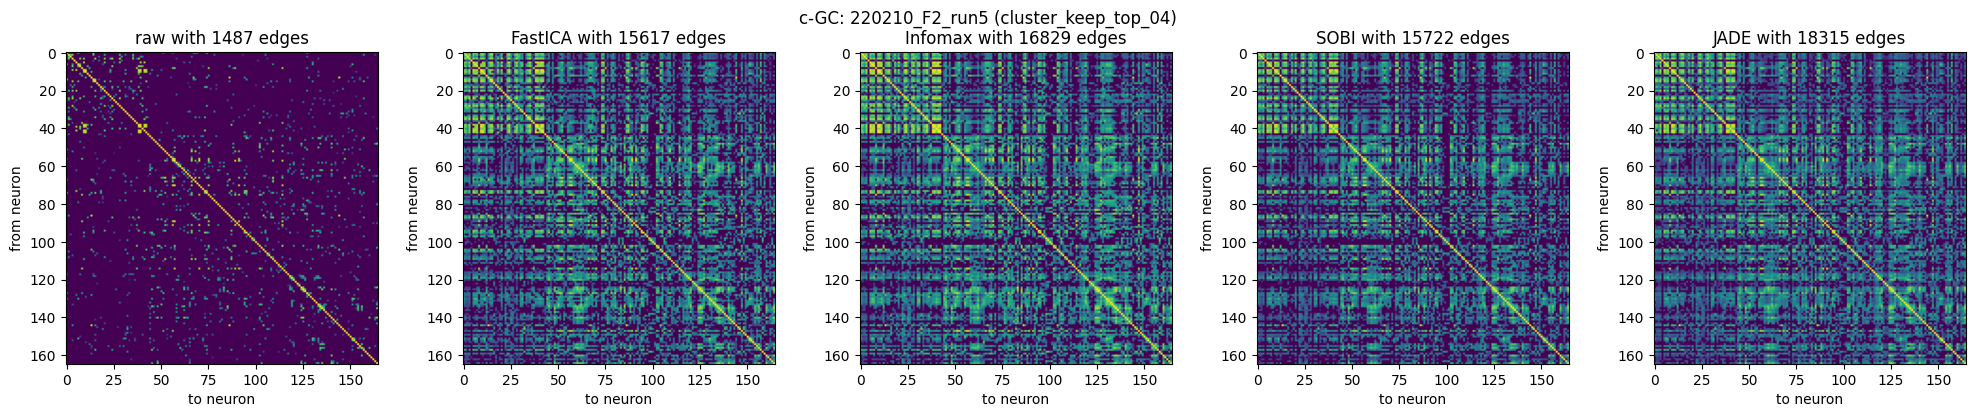

In [6]:
import matplotlib.pyplot as plt

PLOT_ORDER = ["raw", *(f"{method}_cleaned" for method in CLEANED_METHODS)]
VARIANT_TITLES = {
    "raw": "raw",
    "fastica": "FastICA",
    "infomax": "Infomax",
    "sobi": "SOBI",
    "jade": "JADE",
}


def edge_count(matrix: np.ndarray) -> int:
    matrix = np.asarray(matrix)
    return int(np.count_nonzero(matrix != 0) - np.count_nonzero(np.diag(matrix) != 0))


def variant_title(name: str) -> str:
    if name == "raw":
        return "raw"
    method = name.rsplit("_cleaned", 1)[0]
    return VARIANT_TITLES.get(method, method)


fig, axes = plt.subplots(1, len(PLOT_ORDER), figsize=(4 * len(PLOT_ORDER), 4))
for ax, name in zip(np.atleast_1d(axes).ravel(), PLOT_ORDER):
    variant_pickle = OUTPUT_DIR / f"{name}.pkl"
    store = pd.read_pickle(variant_pickle) if variant_pickle.exists() else {}
    if N_PAST not in store:
        ax.set_title(f"{variant_title(name)} (not computed)")
        ax.axis("off")
        continue
    matrix = np.asarray(store[N_PAST], dtype=float)
    ax.imshow(matrix, vmin=0, vmax=max(1.0, float(matrix.max())))
    ax.set_title(f"{variant_title(name)} with {edge_count(matrix)} edges")
    ax.set_xlabel("to neuron")
    ax.set_ylabel("from neuron")

fig.suptitle(f"{METHOD_LABEL}: {DATASET_OUTPUT_NAME} ({CLEANED_VARIANT})")
fig.tight_layout()
MATRIX_FIGURE_PATH = OUTPUT_DIR / "connectivity_matrices_grid.png"
fig.savefig(MATRIX_FIGURE_PATH, dpi=300, bbox_inches="tight")
print(f"Saved figure to {MATRIX_FIGURE_PATH.relative_to(PROJECT_ROOT)}")
plt.show()
